# Codigo: Bravo_Randolph_Chirino_IDA503_Semana7


In [58]:
# Importaciones
import numpy as np  # para operaciones matriciales
import matplotlib.pyplot as plt  # para visualización
from sklearn.cluster import DBSCAN  # para DBSCAN
from sklearn import metrics  # para métricas

In [59]:
X1 = np.random.uniform(low=0, high=1, size=(100, 5))  # 100 filas y 5 columnas
X2 = np.random.uniform(low=2, high=3, size=(100, 5))  # 100 filas y 5 columnas
X = np.vstack((X1, X2))  # Combinar los dos conjuntos de datos en uno solo
print(X.shape)

(200, 5)


In [ ]:
# Configuración de DBSCAN
epsilon = 0.5
min_pts = 5
dbscan = DBSCAN(eps=epsilon, min_samples=min_pts)
clusters = dbscan.fit_predict(X)
np.unique(clusters)

array([-1,  0,  1])

##### En este caso se configura el algoritmo **DBSCAN** con un valor de **`epsilon = 0.5`** y **`min_pts = 5`**, parámetros que determinan la distancia máxima entre vecinos y la cantidad mínima de puntos necesarios para formar un cluster. Posteriormente, mediante **`dbscan.fit_predict(X)`**, el algoritmo analiza los **200 registros** con **5 características** e identifica automáticamente los grupos presentes en los datos según la densidad de las observaciones. Finalmente, utilizando **`np.unique(clusters)`**, se muestran las etiquetas obtenidas por DBSCAN, dando como resultado el array **`[-1, 0, 1]`**, donde **`0`** y **`1`** representan los clusters identificados y **`-1`** corresponde a los registros clasificados como ruido, es decir, aquellos datos que no cumplen con los criterios de densidad establecidos por el algoritmo y, por tanto, no pertenecen a ningún cluster.


In [61]:
valores_unicos, conteos = np.unique(clusters, return_counts=True)
for valor, conteo in zip(valores_unicos, conteos):
    print(f"Valor Único: {valor}, Conteo: {conteo}")

Valor Único: -1, Conteo: 7
Valor Único: 0, Conteo: 97
Valor Único: 1, Conteo: 96


##### Creamos las variables **`valores_unicos`** y **`conteos`**, donde mediante **`np.unique()`** de NumPy obtenemos las etiquetas generadas por **`dbscan.fit_predict(X)`** junto con la cantidad de registros pertenecientes a cada una de ellas. Posteriormente, utilizando el bucle **`for`** junto con las variables **`valor`** y **`conteo`**, recorremos cada etiqueta obtenida para mostrar mediante **`print()`** la cantidad de registros clasificados en cada cluster y los registros identificados como ruido.

##### En este caso, el resultado obtenido fue:

- **`-1`** → **7 registros**, correspondientes al **ruido**.
- **`0`** → **97 registros**, correspondientes al **Cluster 0**.
- **`1`** → **96 registros**, correspondientes al **Cluster 1**.

##### Esto nos permite observar que DBSCAN identificó dos clusters principales y solamente dos registros fueron clasificados como ruido al no cumplir con los criterios de densidad establecidos por el algoritmo.


In [62]:
valores_unicos = np.unique(clusters)

if -1 in valores_unicos:
    numero_clusters = len(valores_unicos) - 1
else:
    numero_clusters = len(valores_unicos)

print(f"Número de Clusters: {numero_clusters}")
print(f"Índice de Silueta: {metrics.silhouette_score(X,clusters)}")

Número de Clusters: 2
Índice de Silueta: 0.6426794555086702


##### Utilizamos la variable creada anteriormente **`valores_unicos`** para conocer la cantidad de clusters reales identificados por DBSCAN. En este caso, los clusters reales corresponden a las etiquetas **`0`** y **`1`**, mientras que la etiqueta **`-1`** representa los registros clasificados como ruido. Posteriormente, mediante una condición **`if`**, verificamos si la etiqueta **`-1`** se encuentra dentro de **`valores_unicos`**. Si existe, se resta una unidad al total de etiquetas encontradas para obtener únicamente la cantidad de clusters reales; en caso contrario `else`, se consideran todos los valores únicos como clusters. Finalmente, mostramos el número de clusters reales y calculamos el **índice de silueta** mediante **`metrics.silhouette_score()`**, el cual permite evaluar la calidad de la agrupación obtenida por el algoritmo DBSCAN. Mientras más cercano sea este valor a **1**, mejor será la separación entre los clusters.

##### Además, cabe señalar que el índice de silueta obtenido (**0.64**) se encuentra dentro de un buen rango de aceptación, lo que indica que los clusters presentan una separación adecuada.


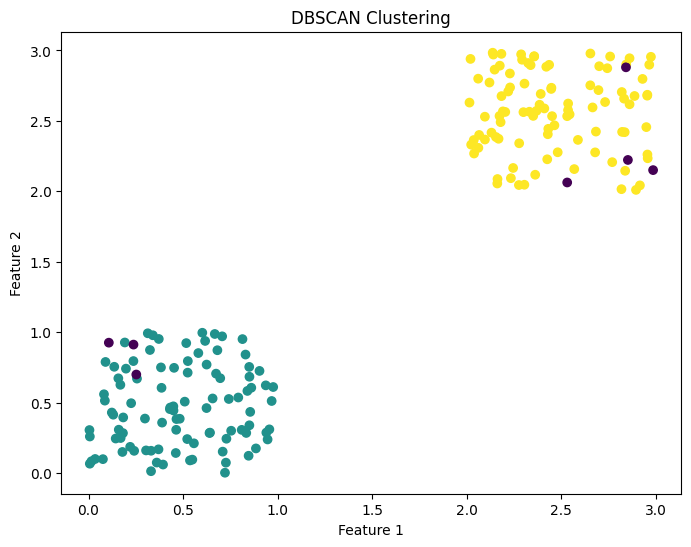

In [63]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

##### Finalmente, graficamos los resultados utilizando la librería **`matplotlib`**. Para ello, empleamos la **característica 1** como eje **X** y la **característica 2** como eje **Y**, mientras que el parámetro **`c=clusters`** asigna un color diferente a cada registro según el cluster identificado por DBSCAN. En la visualización es posible observar los **dos clusters principales** encontrados por el algoritmo y los registros clasificados como **ruido (`-1`)**, los cuales aparecen separados de los grupos principales al no cumplir con los criterios de densidad establecidos por `DBSCAN`.


#####
